# Day 3 — Backpropagation, Gradient Descent & Optimizers

## Overview

This notebook explores the fundamental training process of neural networks using the cleaned cardiovascular disease dataset (cardio_cleaned).

The main goal is to understand how neural networks learn through forward propagation, loss calculation, backpropagation, and weight updates.

The notebook also compares a baseline neural network with an improved model using Batch Normalization, Dropout, and training callbacks.

## Imports and Environment

The experiment uses TensorFlow/Keras for building and training neural networks, Pandas and NumPy for data processing, Scikit-learn for preprocessing and evaluation, and Matplotlib for visualization.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)



## 2. Load the Dataset

The cleaned cardiovascular disease dataset from the previous work is used for this experiment.

The target variable is cardio, which represents whether cardiovascular disease is present.

In [4]:
df = pd.read_csv("/content/cardio_cleaned.csv")

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (68742, 13)


,id,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years
0,0,2,168,62.0,110,80,1,1,0,0,1,0,50.357290
1,1,1,156,85.0,140,90,3,1,0,0,1,1,55.381246
2,2,1,165,64.0,130,70,3,1,0,0,0,1,51.627652
3,3,2,169,82.0,150,100,1,1,0,0,1,1,48.249144
4,4,1,156,56.0,100,60,1,1,0,0,0,0,47.841205


In [6]:
print("Columns:",df.columns.tolist())
print("Missing values:",df.isnull().sum())

print("Duplicate rows:",df.duplicated().sum())
print("Target distribution:",df["cardio"].value_counts())


Columns: ['id', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio', 'age_years']
Missing values: id             0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
age_years      0
dtype: int64
Duplicate rows: 0
Target distribution: cardio
0    34720
1    34022
Name: count, dtype: int64


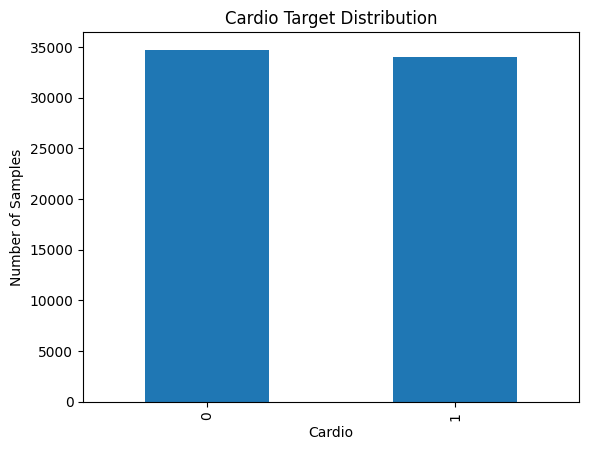

In [7]:
df["cardio"].value_counts().plot(
    kind="bar",
    title="Cardio Target Distribution"
)

plt.xlabel("Cardio")
plt.ylabel("Number of Samples")
plt.show()

##  Features and Target

The cardio column is used as the target variable.

All remaining columns are used as input features for the neural network.

In [9]:
X = df.drop(["cardio", "id"], axis=1)
y = df["cardio"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (68742, 11)
Target shape: (68742,)


## Train-Test Split

The dataset is divided into training and testing sets.

- 80% of the data is used for training.
- 20% is reserved for final testing.
- stratify=y preserves the target class distribution in both sets.

The test set will remain unseen during training and will only be used for final evaluation.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 54993
Testing samples: 13749


##  Feature Scaling

Neural networks generally train more effectively when numerical features are on comparable scales.

StandardScaler transforms the features so that they have approximately zero mean and unit variance.

The scaler is fitted only on the training data to prevent data leakage.

In [11]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training data shape:", X_train_scaled.shape)
print("Testing data shape:", X_test_scaled.shape)

Training data shape: (54993, 11)
Testing data shape: (13749, 11)


##  The Four-Step Training Loop

Training a neural network follows four main steps:

### 1. Forward Pass

The input data moves through the network and produces predictions.

### 2. Loss Calculation

The loss function measures the difference between the predictions and the true labels.

### 3. Backpropagation

The gradients of the loss with respect to the model's weights are calculated using the Chain Rule.

### 4. Weight Update

The optimizer uses the calculated gradients to update the weights in a direction that reduces the loss.

The process is repeated for multiple batches and epochs.

**Training Loop:**

Forward Pass → Loss → Backpropagation → Weight Update

##  Baseline Neural Network

A simple neural network is first created as a baseline.

The purpose of the baseline is to establish an initial performance level before introducing improvements such as Batch Normalization, Dropout, and callbacks.

The baseline model contains:

- Two Dense hidden layers
- ReLU activation functions
- One Sigmoid output neuron for binary classification

The Adam optimizer is used with a learning rate of 0.001.

In [27]:
def build_baseline_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(X_train_scaled.shape[1],)),

        tf.keras.layers.Dense( 16,activation="relu"),

        tf.keras.layers.Dense(8,activation="relu" ),

        tf.keras.layers.Dense(1,activation="sigmoid")
    ])

    return model

In [28]:
baseline_model = build_baseline_model()

baseline_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

baseline_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 16)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 337 (1.32 KB)

 Trainable params: 337 (1.32 KB)

 Non-trainable params: 0 (0.00 B)

##  Baseline Training

The baseline model is trained for a fixed number of epochs using batches of 32 samples.

The validation set is used to monitor how well the model generalizes to unseen training examples.

At this stage, no EarlyStopping or ModelCheckpoint is used because this model serves as our baseline for comparison.

In [30]:
baseline_history = baseline_model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    verbose=1
)

Epoch 1/20
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7307 - loss: 0.5455 - val_accuracy: 0.7340 - val_loss: 0.5431
Epoch 2/20
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.7305 - loss: 0.5447 - val_accuracy: 0.7338 - val_loss: 0.5439
Epoch 3/20
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.7308 - loss: 0.5444 - val_accuracy: 0.7374 - val_loss: 0.5431
Epoch 4/20
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7318 - loss: 0.5437 - val_accuracy: 0.7339 - val_loss: 0.5428
Epoch 5/20
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.7311 - loss: 0.5434 - val_accuracy: 0.7329 - val_loss: 0.5447
Epoch 6/20
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7325 - loss: 0.5431 - val_accuracy: 0.7346 - val_loss: 0.5430
Epoch 7/20
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7321 - loss: 0.5425 - val_accuracy: 0.7349 - val_loss: 0.5437
Epoch 8/20
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7330 - loss: 0.5428 -

##  Baseline Training Curves

Training and validation loss are plotted to examine the learning behavior of the baseline model.

Comparing the two curves helps identify whether the model is learning effectively or showing signs of underfitting or overfitting.

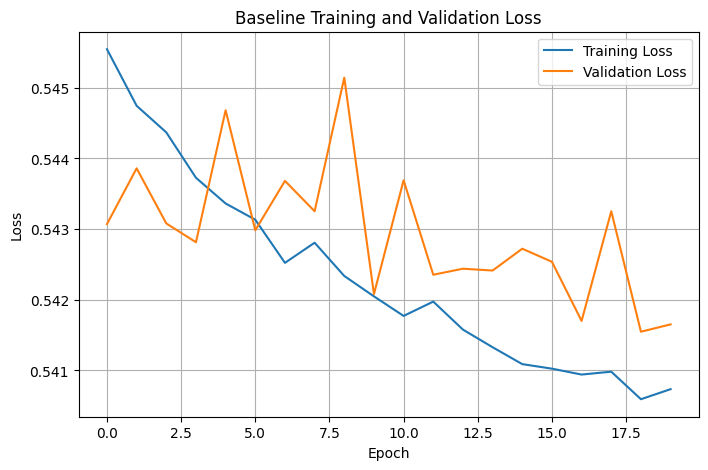

In [31]:
plt.figure(figsize=(8, 5))

plt.plot(
    baseline_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    baseline_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

##  Baseline Analysis

The baseline model achieved approximately **73% training accuracy** and **74% validation accuracy**.

The training and validation losses remained close throughout the training process, which indicates that there is no strong evidence of overfitting.

However, the loss decreased only slightly during the 20 epochs, while the accuracy remained around the same level. This suggests that the baseline model has limited learning capacity and may be underfitting the data.

This baseline provides a reference point for evaluating whether architectural and training improvements can produce better performance.

##  Gradient Descent and Learning Rate

Gradient Descent is an optimization method used to minimize the model's loss.

During backpropagation, the gradients of the loss with respect to the model's weights are calculated. The optimizer then uses these gradients to update the weights.

The learning rate determines the size of these updates.

A very high learning rate may cause unstable updates or overshoot the minimum, while a very low learning rate can make training unnecessarily slow.

To observe this effect, three different learning rates will be compared while keeping the network architecture and training settings unchanged.

In [33]:
learning_rates = {
    "High": 0.1,
    "Default": 0.001,
    "Low": 0.00001
}

lr_histories = {}

In [34]:
for name, lr in learning_rates.items():

    print(f"\nTraining with {name} learning rate: {lr}")

    model = build_baseline_model()

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=lr
        ),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    history = model.fit(
        X_train_scaled,
        y_train,
        validation_split=0.2,
        epochs=20,
        batch_size=32,
        verbose=0
    )

    lr_histories[name] = history


Training with High learning rate: 0.1

Training with Default learning rate: 0.001

Training with Low learning rate: 1e-05


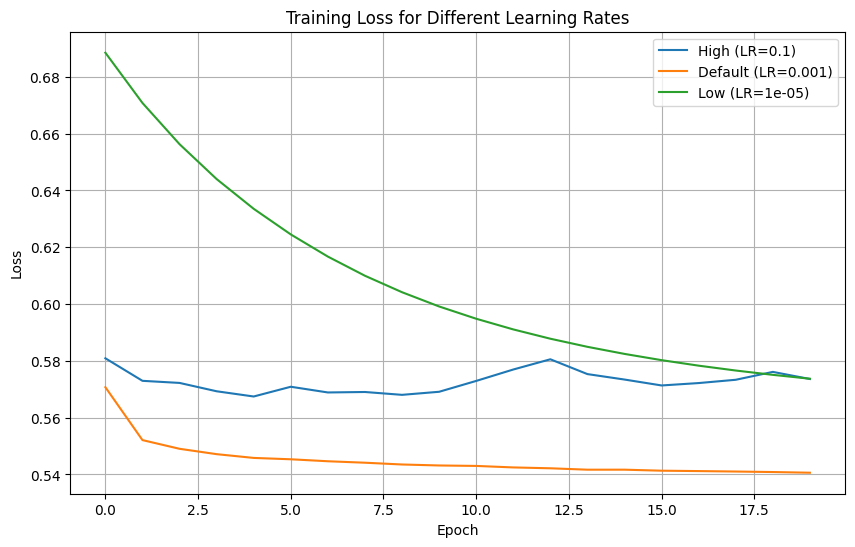

In [35]:
plt.figure(figsize=(10, 6))

for name, history in lr_histories.items():
    plt.plot(
        history.history["loss"],
        label=f"{name} (LR={learning_rates[name]})"
    )

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss for Different Learning Rates")
plt.legend()
plt.grid(True)
plt.show()

##  Learning Rate Analysis

The three learning rates produced noticeably different training behaviors.

### Low Learning Rate — 0.00001

The loss started at approximately 0.68 and gradually decreased to around 0.58.

The model was able to learn, but the decrease was relatively slow. This demonstrates that a very small learning rate results in small weight updates, which can make convergence slower.

### High Learning Rate — 0.1

The loss started at approximately 0.58 and initially decreased to around 0.56. It then increased again toward 0.58 before decreasing slightly to approximately 0.57.

This fluctuation indicates that the learning rate was relatively large for this optimization problem. The larger weight updates caused the optimization process to move back and forth around regions of the loss surface instead of converging smoothly.

### Default Learning Rate — 0.001

The loss started at approximately 0.57 and gradually decreased to around 0.54.

Among the three tested learning rates, 0.001 achieved the lowest final loss and showed the most stable convergence.

### Conclusion

The experiment demonstrates the effect of the learning rate on the optimization process.

A very small learning rate resulted in slow convergence, while the high learning rate produced noticeable fluctuations in the loss.

The learning rate of 0.001 provided the most stable and effective convergence among the tested values.

This experiment shows that choosing an appropriate learning rate is important for allowing gradient-based optimization to reduce the loss efficiently.

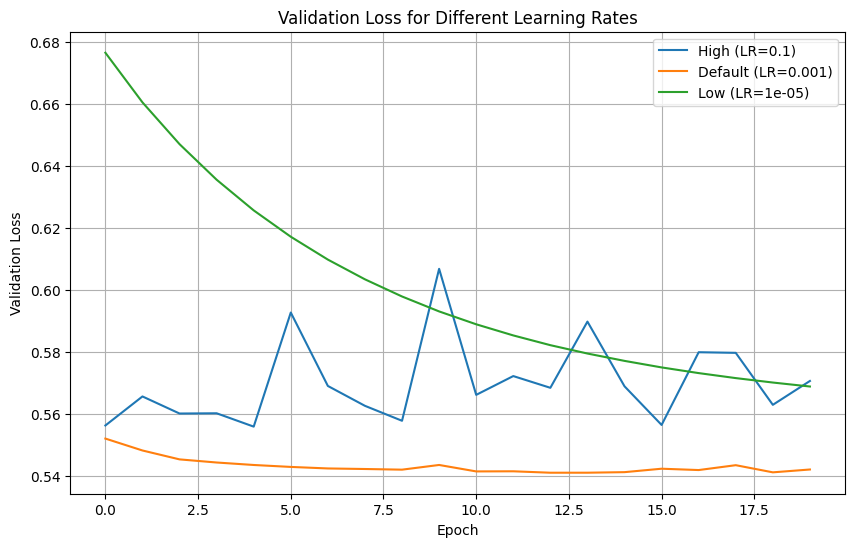

In [36]:
plt.figure(figsize=(10, 6))

for name, history in lr_histories.items():
    plt.plot(
        history.history["val_loss"],
        label=f"{name} (LR={learning_rates[name]})"
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss for Different Learning Rates")
plt.legend()
plt.grid(True)
plt.show()

##  Validation Loss Analysis

The validation loss provides additional information about how well the models generalize beyond the training data.

### Low Learning Rate — 0.00001

The validation loss started at approximately 0.68 and gradually decreased to around 0.57.

The curve was relatively smooth, indicating stable learning. However, the slow decrease shows that the learning rate is too small to achieve fast convergence.

### High Learning Rate — 0.1

The validation loss started at approximately 0.55 and showed noticeable fluctuations, moving between approximately 0.55 and 0.61.

This unstable behavior suggests that the learning rate is too large for this optimization problem. Large weight updates can cause the optimizer to overshoot useful regions of the loss surface, resulting in oscillations rather than smooth convergence.

### Default Learning Rate — 0.001

The validation loss started at approximately 0.55 and gradually decreased to around 0.54.

The curve showed the most stable behavior among the tested learning rates and achieved the lowest final validation loss.

### Conclusion

The comparison shows the importance of selecting an appropriate learning rate.

- 0.00001 produced stable but slow convergence.
- 0.1 produced unstable validation behavior.
- 0.001 provided the best balance between convergence and stability.

Therefore, 0.001 was selected as the learning rate for the next stage of model development.

##  Backpropagation

Backpropagation is the process used to calculate how much each model weight contributed to the final loss.

After the forward pass produces a prediction and the loss function measures the error, backpropagation works backward through the network.

It uses the Chain Rule of calculus to calculate the gradient of the loss with respect to each trainable parameter.

These gradients tell the optimizer how the weights should be adjusted to reduce the loss.

In practice, TensorFlow performs these calculations automatically using automatic differentiation.

## The Chain Rule

The Chain Rule allows the gradient of the final loss to be propagated backward through multiple layers.

Conceptually:

Loss
↓
Output Layer
↓
Hidden Layer
↓
Input Layer

For each weight, the gradient answers the question:

"How much would the loss change if this weight changed slightly?"

The optimizer then uses these gradients to update the weights.

Therefore, the training process can be summarized as:

Forward Pass → Calculate Loss → Backpropagation → Calculate Gradients → Update Weights

## Observing Backpropagation with GradientTape

TensorFlow's GradientTape automatically records the operations performed during the forward pass.

After calculating the loss, it can compute the gradients of the loss with respect to the model's trainable weights.

This demonstrates the main idea of backpropagation without manually implementing the Chain Rule.

In [38]:

demo_model = build_baseline_model()

demo_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy"
)


X_batch = X_train_scaled[:32]
y_batch = y_train.iloc[:32].values.reshape(-1, 1)

with tf.GradientTape() as tape:
    predictions = demo_model(X_batch, training=True)

    loss = tf.keras.losses.binary_crossentropy(
        y_batch,
        predictions
    )

    loss = tf.reduce_mean(loss)

gradients = tape.gradient(
    loss,
    demo_model.trainable_variables
)

print("Loss:", float(loss))

print("\nGradient shapes:")

for variable, gradient in zip(
    demo_model.trainable_variables,
    gradients
):
    print(variable.name, gradient.shape)

Loss: 0.6902691125869751

Gradient shapes:
kernel (11, 16)
bias (16,)
kernel (16, 8)
bias (8,)
kernel (8, 1)
bias (1,)


In [39]:
optimizers = {
    "Adam": tf.keras.optimizers.Adam(learning_rate=0.001),
    "SGD": tf.keras.optimizers.SGD(learning_rate=0.001)
}

optimizer_histories = {}

for name, optimizer in optimizers.items():

    print(f"Training with {name}")

    model = build_baseline_model()

    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    history = model.fit(
        X_train_scaled,
        y_train,
        validation_split=0.2,
        epochs=20,
        batch_size=32,
        verbose=0
    )

    optimizer_histories[name] = history

Training with Adam
Training with SGD


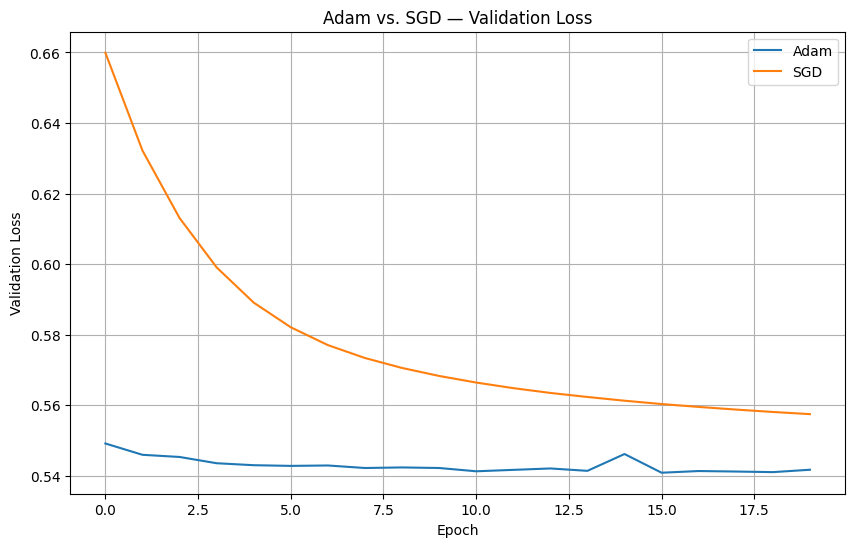

In [40]:
plt.figure(figsize=(10, 6))

for name, history in optimizer_histories.items():

    plt.plot(
        history.history["val_loss"],
        label=name
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Adam vs. SGD — Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

##  Adam vs. SGD Analysis

The validation loss curves show different optimization behaviors for Adam and SGD.

### Adam

Adam started with a validation loss of approximately 0.66 and gradually decreased to around 0.55.

The relatively smooth decrease indicates that Adam was able to make consistent progress during optimization.

### SGD

SGD started at approximately 0.55 and initially decreased slightly to around 0.54.

The validation loss then remained relatively stable, followed by a small increase toward 0.55 before returning close to its previous level.

This indicates that SGD made limited progress and reached a relatively stable region early in training.

### Conclusion

The two optimizers demonstrated different optimization behaviors.

Adam showed a clearer decrease in validation loss throughout training, while SGD showed smaller improvements followed by stabilization and minor fluctuations.

This experiment demonstrates that the choice of optimizer can affect the speed and behavior of convergence, even when the network architecture and learning rate remain unchanged.

In [41]:
def build_improved_model():

    model = tf.keras.Sequential([

        tf.keras.layers.Input(
            shape=(X_train_scaled.shape[1],)
        ),

        tf.keras.layers.Dense(32),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation("relu"),
        tf.keras.layers.Dropout(0.3),

        tf.keras.layers.Dense(16),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation("relu"),
        tf.keras.layers.Dropout(0.2),

        tf.keras.layers.Dense(
            1,
            activation="sigmoid"
        )
    ])

    return model

##  Model Compilation

The improved model is compiled using:

- Binary Crossentropy as the loss function because this is a binary classification problem.
- Adam as the optimizer.
- A learning rate of 0.001 based on the previous learning rate experiment.
- Accuracy as an initial training metric.

In [42]:
improved_model = build_improved_model()

improved_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

improved_model.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_39 (Dense)                │ (None, 32)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,121 (4.38 KB)

 Trainable params: 1,025 (4.00 KB)

 Non-trainable params: 96 (384.00 B)

## Training Callbacks

Two callbacks are used to make the training process more reliable.

### EarlyStopping

EarlyStopping monitors the validation loss and stops training when the model stops improving.

The best weights are restored after training.

### ModelCheckpoint

ModelCheckpoint saves the model with the best validation loss during training.

These callbacks help reduce unnecessary training and preserve the best-performing version of the model.

In [43]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_cardio_model.keras",
    monitor="val_loss",
    save_best_only=True
)

In [44]:
improved_history = improved_model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[
        early_stopping,
        checkpoint
    ],
    verbose=1
)

Epoch 1/50
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.6763 - loss: 0.6189 - val_accuracy: 0.7327 - val_loss: 0.5537
Epoch 2/50
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7156 - loss: 0.5728 - val_accuracy: 0.7355 - val_loss: 0.5476
Epoch 3/50
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7188 - loss: 0.5670 - val_accuracy: 0.7341 - val_loss: 0.5453
Epoch 4/50
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7201 - loss: 0.5643 - val_accuracy: 0.7320 - val_loss: 0.5453
Epoch 5/50
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7230 - loss: 0.5620 - val_accuracy: 0.7356 - val_loss: 0.5440
Epoch 6/50
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7223 - loss: 0.5634 - val_accuracy: 0.7356 - val_loss: 0.5444
Epoch 7/50
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7249 - loss: 0.5599 - val_accuracy: 0.7327 - val_loss: 0.5429
Epoch 8/50
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7221 - loss: 0.5607 -

##  Improved Model Training Curves

The improved model was trained for a maximum of 50 epochs, but EarlyStopping terminated training at epoch 19 because the validation loss stopped improving.

The training and validation curves are examined to understand the model's learning behavior and determine whether the additional architecture and regularization techniques improved generalization.

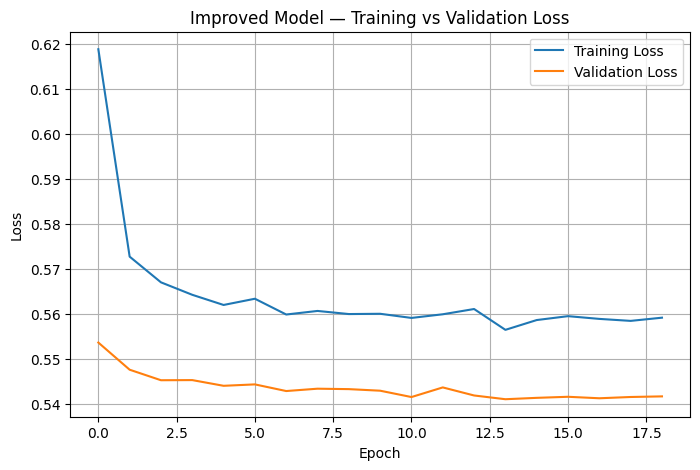

In [45]:
plt.figure(figsize=(8, 5))

plt.plot(
    improved_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    improved_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Improved Model — Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

In [46]:
best_epoch = np.argmin(
    improved_history.history["val_loss"]
) + 1

best_val_loss = min(
    improved_history.history["val_loss"]
)

best_val_accuracy = max(
    improved_history.history["val_accuracy"]
)

print("Best Epoch:", best_epoch)
print("Best Validation Loss:", best_val_loss)
print("Best Validation Accuracy:", best_val_accuracy)

Best Epoch: 14
Best Validation Loss: 0.5410532355308533
Best Validation Accuracy: 0.7385216951370239


##  Final Test Set Evaluation

The test set was not used during model training and therefore provides an unbiased estimate of the model's generalization performance.

The final model is evaluated using:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix

Using multiple metrics provides a more complete evaluation than accuracy alone.

In [47]:
y_prob = improved_model.predict(
    X_test_scaled,
    verbose=0
)

y_pred = (y_prob >= 0.5).astype(int).ravel()

In [48]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

Accuracy:  0.7336
Precision: 0.7489
Recall:    0.6946
F1-score:  0.7207


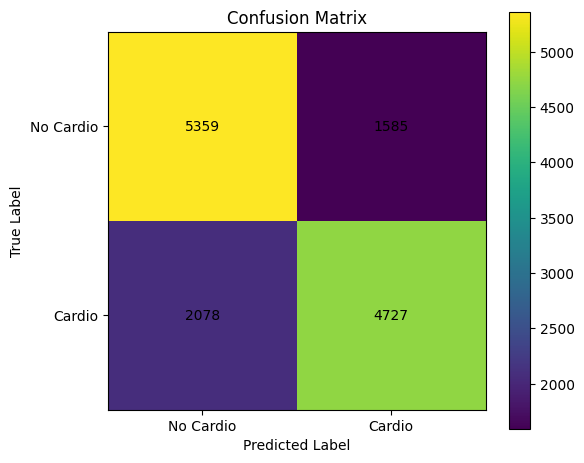

In [49]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

plt.imshow(
    cm,
    cmap="viridis"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.colorbar()

plt.xticks(
    [0, 1],
    ["No Cardio", "Cardio"]
)

plt.yticks(
    [0, 1],
    ["No Cardio", "Cardio"]
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

##  Final Conclusion

This notebook demonstrated the complete neural network training process, including forward propagation, loss calculation, backpropagation, gradient descent, learning rate selection, optimizer comparison, and model evaluation.

The learning rate experiment showed that 0.001 provided the most stable convergence among the tested values.

The Backpropagation experiment using TensorFlow's GradientTape demonstrated how gradients are calculated for the trainable parameters of the network.

The improved model achieved a best validation accuracy of approximately 73.85% and a validation loss of 0.5411. On the unseen test set, it achieved 73.36% accuracy, 74.89% precision, 69.46% recall, and a 72.07% F1-score.

Although the architectural improvements did not produce a large performance increase, the experiments demonstrated how learning rate, optimization, regularization, and callbacks affect neural network training and generalization.

The main takeaway is that neural network performance should be improved through systematic experimentation and evaluation rather than relying on architectural changes alone.